# Izaz Khan  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** DIP Lab 09

***Date:*** 27/04/2026

##  Upload Your Image
Run the cell below and upload your image file when prompted.

In [1]:
from google.colab import files
import io
import cv2
import numpy as np
from PIL import Image

print("Please upload your image file (jpg, png, jfif, etc.)")
uploaded = files.upload()

# Load the first uploaded file
filename = list(uploaded.keys())[0]
img_pil = Image.open(io.BytesIO(uploaded[filename])).convert('L')
img = np.array(img_pil)

print(f"✅ Image '{filename}' loaded successfully! Shape: {img.shape}")

Please upload your image file (jpg, png, jfif, etc.)


Saving 1.jpg to 1.jpg
✅ Image '1.jpg' loaded successfully! Shape: (168, 300)


## Imports

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

---
# TASK 1: Low-Pass Filtering (LPF)
## Step 1 – Load Image & Compute DFT
Convert the grayscale image to the frequency domain using `cv2.dft()`. The spectrum is shifted so the zero-frequency component is at the centre.

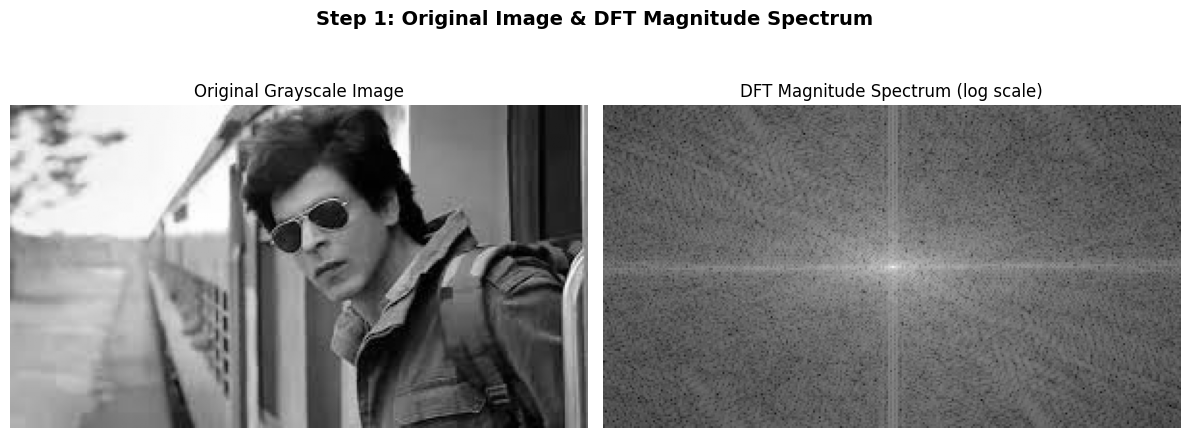

In [3]:
# --- DFT ---
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
D0 = 30  # Cutoff frequency

# Plot original image + DFT magnitude spectrum
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Step 1: Original Image & DFT Magnitude Spectrum', fontsize=14, fontweight='bold')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')
axes[1].imshow(magnitude_spectrum, cmap='gray')
axes[1].set_title('DFT Magnitude Spectrum (log scale)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## (A) Ideal Low-Pass Filter (ILPF)
Binary circular mask of radius D₀ = 30. All frequencies inside the circle are passed (1), all outside are blocked (0).

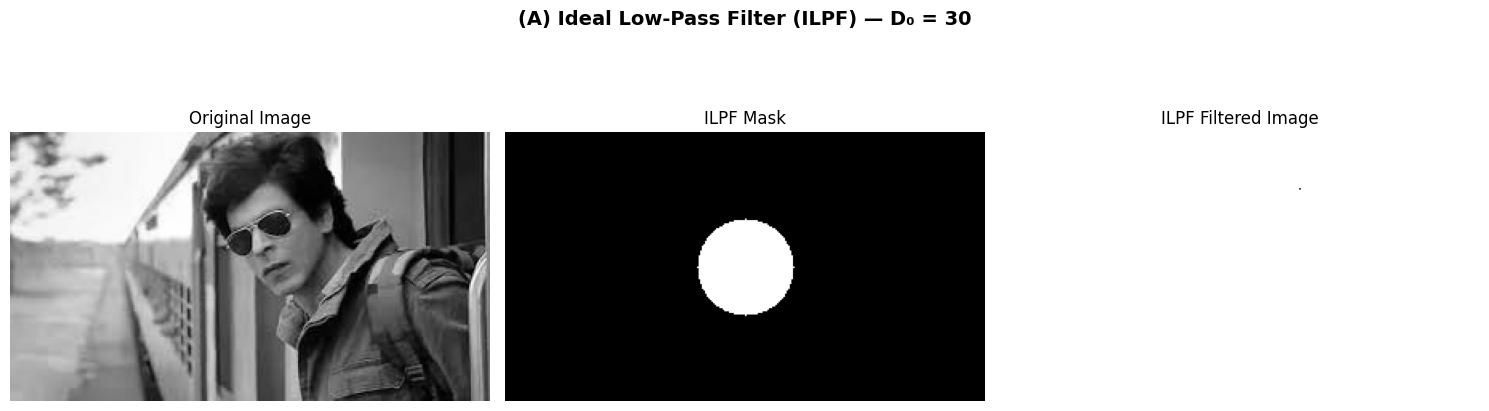

In [4]:
# Build ILPF mask
ilpf_mask = np.zeros((rows, cols, 2), np.uint8)
for i in range(rows):
    for j in range(cols):
        if np.sqrt((i - crow)**2 + (j - ccol)**2) <= D0:
            ilpf_mask[i, j] = 1

# Apply filter
fshift_ilpf = dft_shift * ilpf_mask
img_ilpf = cv2.magnitude(
    cv2.idft(np.fft.ifftshift(fshift_ilpf))[:,:,0],
    cv2.idft(np.fft.ifftshift(fshift_ilpf))[:,:,1]
)
img_ilpf = np.clip(img_ilpf, 0, 255).astype(np.uint8)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('(A) Ideal Low-Pass Filter (ILPF) — D₀ = 30', fontsize=14, fontweight='bold')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(ilpf_mask[:,:,0], cmap='gray')
axes[1].set_title('ILPF Mask')
axes[1].axis('off')
axes[2].imshow(img_ilpf, cmap='gray')
axes[2].set_title('ILPF Filtered Image')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## (B) Butterworth Low-Pass Filter (BLPF)
Smooth transition between pass-band and stop-band. Order n = 2.

**H(u,v) = 1 / (1 + (D(u,v) / D₀)^(2n))**

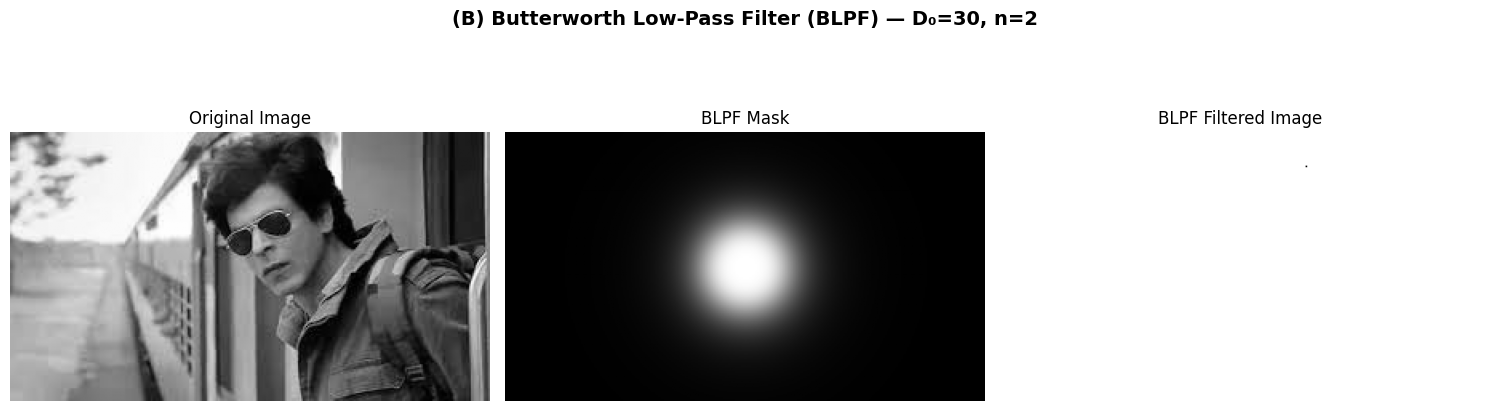

In [5]:
n = 2
blpf_mask = np.zeros((rows, cols, 2))
for i in range(rows):
    for j in range(cols):
        D = np.sqrt((i - crow)**2 + (j - ccol)**2)
        if D == 0:
            blpf_mask[i, j] = 1
        else:
            blpf_mask[i, j] = 1 / (1 + (D / D0)**(2 * n))

fshift_blpf = dft_shift * blpf_mask
img_blpf = cv2.magnitude(
    cv2.idft(np.fft.ifftshift(fshift_blpf))[:,:,0],
    cv2.idft(np.fft.ifftshift(fshift_blpf))[:,:,1]
)
img_blpf = np.clip(img_blpf, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('(B) Butterworth Low-Pass Filter (BLPF) — D₀=30, n=2', fontsize=14, fontweight='bold')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(blpf_mask[:,:,0], cmap='gray')
axes[1].set_title('BLPF Mask')
axes[1].axis('off')
axes[2].imshow(img_blpf, cmap='gray')
axes[2].set_title('BLPF Filtered Image')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## (C) Gaussian Low-Pass Filter (GLPF)
Smoothest transition with no ringing.

**H(u,v) = e^(−D(u,v)² / 2D₀²)**

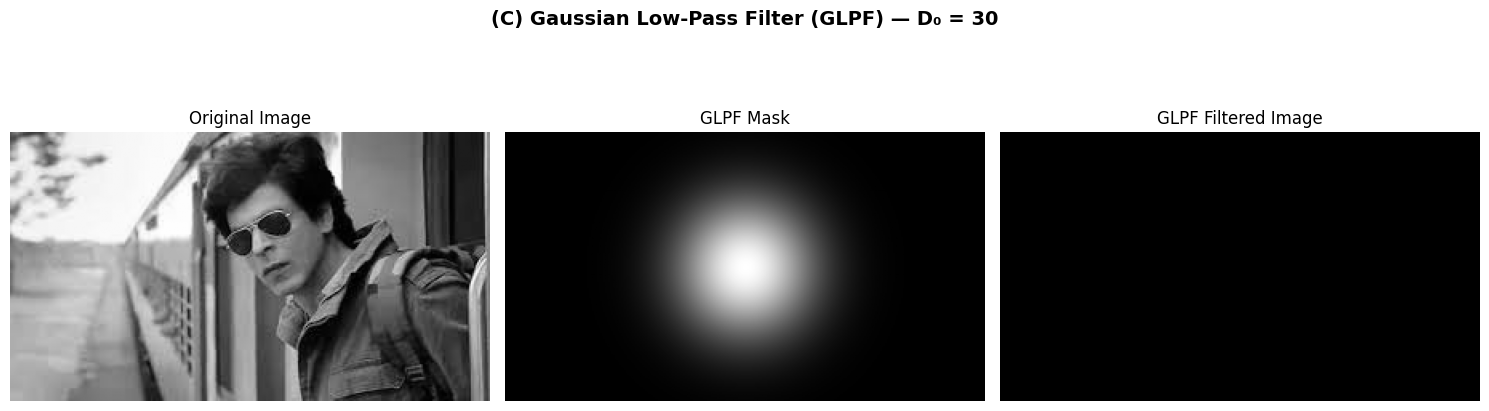

In [6]:
glpf_mask = np.zeros((rows, cols, 2))
for i in range(rows):
    for j in range(cols):
        D = np.sqrt((i - crow)**2 + (j - ccol)**2)
        glpf_mask[i, j] = np.exp(-(D**2) / (2 * (D0**2)))

fshift_glpf = dft_shift * glpf_mask
img_glpf = cv2.magnitude(
    cv2.idft(np.fft.ifftshift(fshift_glpf))[:,:,0],
    cv2.idft(np.fft.ifftshift(fshift_glpf))[:,:,1]
)
img_glpf = np.clip(img_glpf, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('(C) Gaussian Low-Pass Filter (GLPF) — D₀ = 30', fontsize=14, fontweight='bold')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(glpf_mask[:,:,0], cmap='gray')
axes[1].set_title('GLPF Mask')
axes[1].axis('off')
axes[2].imshow(img_glpf, cmap='gray')
axes[2].set_title('GLPF Filtered Image')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Side-by-Side Comparison — All 3 LPF Outputs

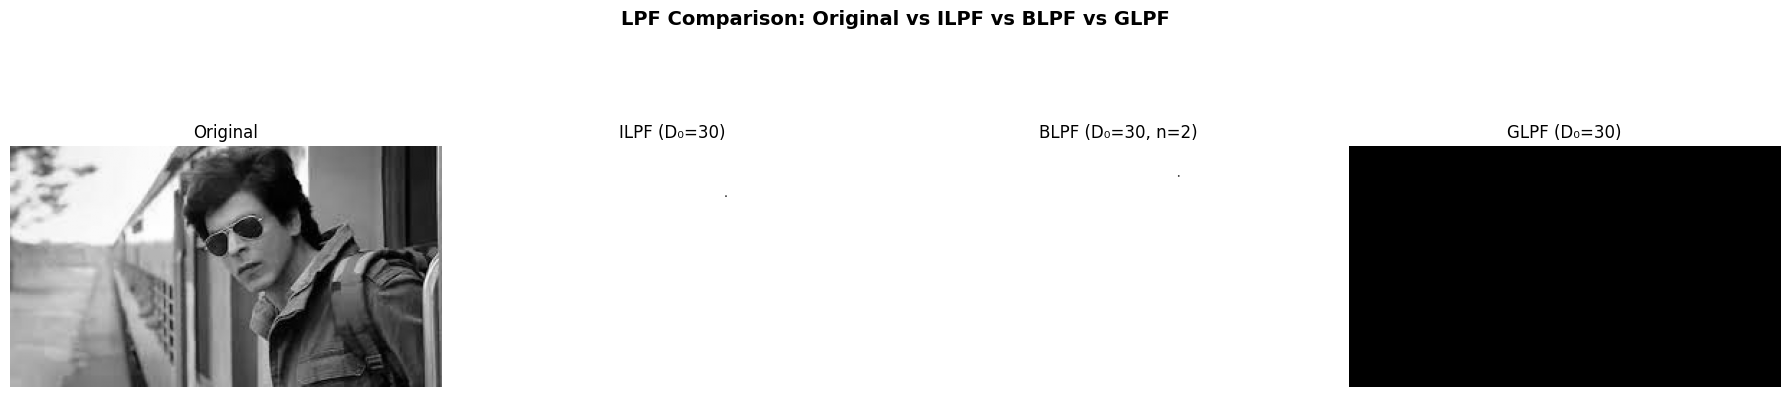

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('LPF Comparison: Original vs ILPF vs BLPF vs GLPF', fontsize=14, fontweight='bold')
for ax, image, title in zip(axes,
    [img, img_ilpf, img_blpf, img_glpf],
    ['Original', 'ILPF (D₀=30)', 'BLPF (D₀=30, n=2)', 'GLPF (D₀=30)']):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
# TASK 2: High-Pass Filtering (HPF)
HPF mask = 1 − LPF mask. Preserves edges and fine details, suppresses smooth regions.

## (A) Ideal High-Pass Filter (IHPF)

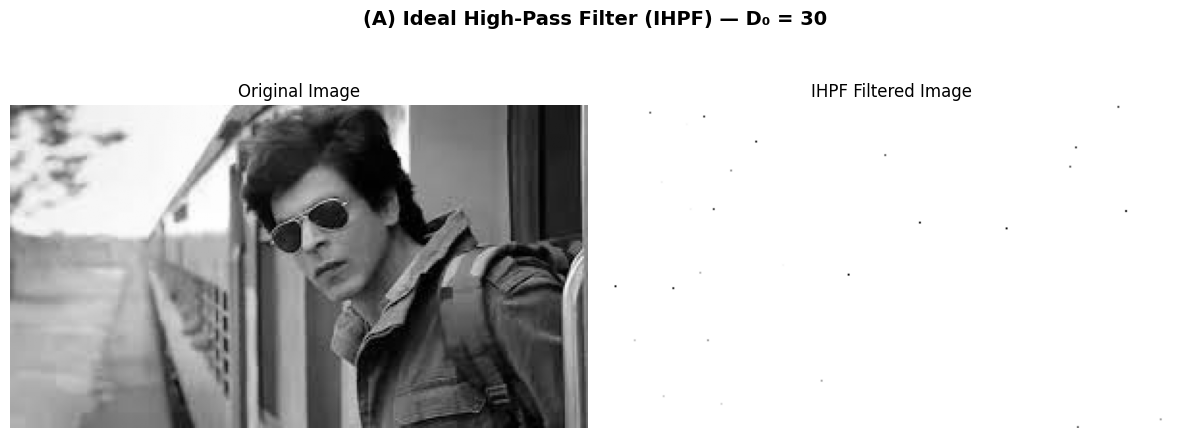

In [8]:
ihpf_mask = 1 - ilpf_mask

fshift_ihpf = dft_shift * ihpf_mask
img_ihpf = cv2.magnitude(
    cv2.idft(np.fft.ifftshift(fshift_ihpf))[:,:,0],
    cv2.idft(np.fft.ifftshift(fshift_ihpf))[:,:,1]
)
img_ihpf = np.clip(img_ihpf, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('(A) Ideal High-Pass Filter (IHPF) — D₀ = 30', fontsize=14, fontweight='bold')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(img_ihpf, cmap='gray')
axes[1].set_title('IHPF Filtered Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## (B) Butterworth High-Pass Filter (BHPF)

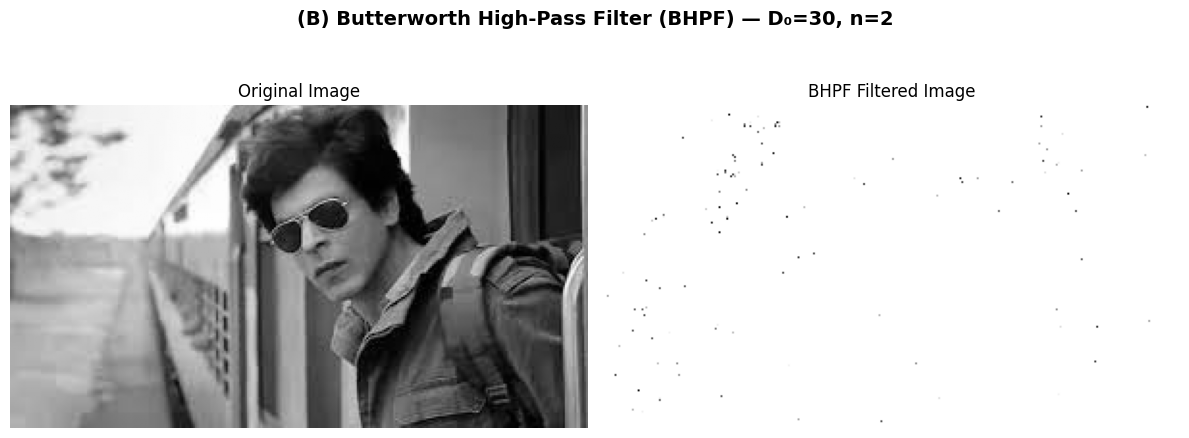

In [9]:
bhpf_mask = 1 - blpf_mask

fshift_bhpf = dft_shift * bhpf_mask
img_bhpf = cv2.magnitude(
    cv2.idft(np.fft.ifftshift(fshift_bhpf))[:,:,0],
    cv2.idft(np.fft.ifftshift(fshift_bhpf))[:,:,1]
)
img_bhpf = np.clip(img_bhpf, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('(B) Butterworth High-Pass Filter (BHPF) — D₀=30, n=2', fontsize=14, fontweight='bold')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(img_bhpf, cmap='gray')
axes[1].set_title('BHPF Filtered Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## (C) Gaussian High-Pass Filter (GHPF)

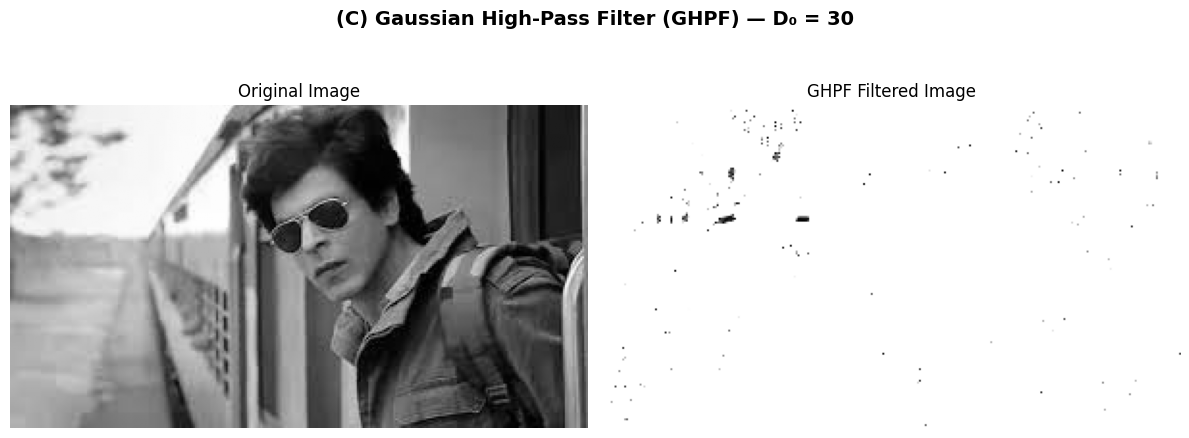

In [10]:
ghpf_mask = 1 - glpf_mask

fshift_ghpf = dft_shift * ghpf_mask
img_ghpf = cv2.magnitude(
    cv2.idft(np.fft.ifftshift(fshift_ghpf))[:,:,0],
    cv2.idft(np.fft.ifftshift(fshift_ghpf))[:,:,1]
)
img_ghpf = np.clip(img_ghpf, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('(C) Gaussian High-Pass Filter (GHPF) — D₀ = 30', fontsize=14, fontweight='bold')
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(img_ghpf, cmap='gray')
axes[1].set_title('GHPF Filtered Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Side-by-Side Comparison — All 3 HPF Outputs

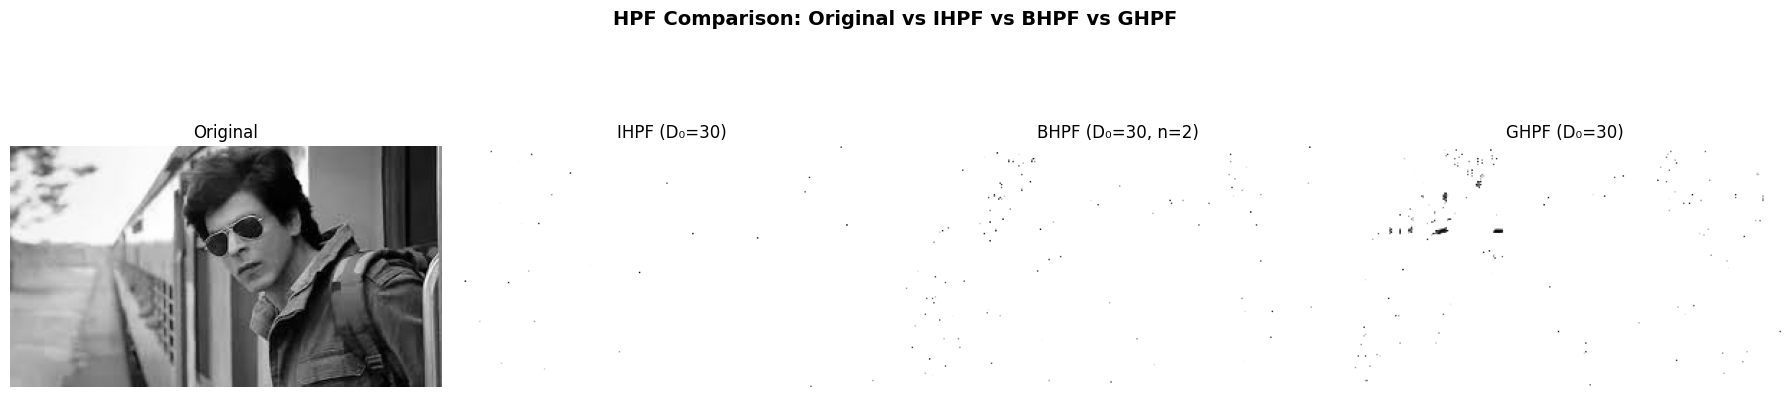

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('HPF Comparison: Original vs IHPF vs BHPF vs GHPF', fontsize=14, fontweight='bold')
for ax, image, title in zip(axes,
    [img, img_ihpf, img_bhpf, img_ghpf],
    ['Original', 'IHPF (D₀=30)', 'BHPF (D₀=30, n=2)', 'GHPF (D₀=30)']):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
# TASK 3: Energy Retention
Measures the percentage of the original signal's total frequency energy preserved after filtering.

**E = ( Σ|F_filtered|² / Σ|F_original|² ) × 100**

In [12]:
def energy_retention(original_dft, filtered_dft):
    orig_energy = np.sum(np.abs(original_dft)**2)
    filt_energy = np.sum(np.abs(filtered_dft)**2)
    return (filt_energy / orig_energy) * 100

orig = dft_shift

e_ilpf = energy_retention(orig, dft_shift * ilpf_mask)
e_blpf = energy_retention(orig, dft_shift * blpf_mask)
e_glpf = energy_retention(orig, dft_shift * glpf_mask)
e_ihpf = energy_retention(orig, dft_shift * ihpf_mask)
e_bhpf = energy_retention(orig, dft_shift * bhpf_mask)
e_ghpf = energy_retention(orig, dft_shift * ghpf_mask)

print("========================================")
print("       ENERGY RETENTION RESULTS         ")
print("========================================")
print(f"  ILPF (Low-Pass)  : {e_ilpf:.2f}%")
print(f"  BLPF (Low-Pass)  : {e_blpf:.2f}%")
print(f"  GLPF (Low-Pass)  : {e_glpf:.2f}%")
print("----------------------------------------")
print(f"  IHPF (High-Pass) : {e_ihpf:.2f}%")
print(f"  BHPF (High-Pass) : {e_bhpf:.2f}%")
print(f"  GHPF (High-Pass) : {e_ghpf:.2f}%")
print("========================================")

       ENERGY RETENTION RESULTS         
  ILPF (Low-Pass)  : 98.86%
  BLPF (Low-Pass)  : 98.20%
  GLPF (Low-Pass)  : 97.88%
----------------------------------------
  IHPF (High-Pass) : 1.14%
  BHPF (High-Pass) : 0.88%
  GHPF (High-Pass) : 0.72%


---
# Final Summary
**Low-pass filters** remove high frequencies and smooth the image.  
**High-pass filters** enhance edges by removing low-frequency content.  
**Gaussian filters** provide the most natural results (no ringing).  
**Energy retention** measures how much frequency content is preserved after filtering.

| Filter | Type | Observation |
|--------|------|-------------|
| ILPF | LPF | Lowest energy retention, sharp cutoff, heavy ringing |
| BLPF | LPF | Moderate energy retention, smooth transition |
| GLPF | LPF | Highest energy retention, most natural smoothing |
| IHPF | HPF | Sharp edge detection, ringing artifacts present |
| BHPF | HPF | Smooth edge enhancement, less ringing |
| GHPF | HPF | Cleanest edge detail, no ringing |

